# FYP: Player Performance Analytics for Team Selection and Cost Optimization in Football


In [5]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load the dataset

In [6]:
from google.colab import files
uploaded = files.upload()

dataset_path = None # Initialize dataset_path to ensure it's always defined

if uploaded:
    # files.upload() returns a dictionary {filename: content}. We take the first filename.
    dataset_path = list(uploaded.keys())[0]
    print(f"File '{dataset_path}' uploaded successfully.")
else:
    print("No file was uploaded. Please upload a dataset.")
    # Depending on requirements, you might want to raise an error or try a default path here.

df = pd.read_csv(dataset_path)
print("Dataset loaded from:", dataset_path)
print("Shape:", df.shape)
df.head()

Saving CLEAN_FIFA23_official_data.csv to CLEAN_FIFA23_official_data (2).csv
File 'CLEAN_FIFA23_official_data (2).csv' uploaded successfully.
Dataset loaded from: CLEAN_FIFA23_official_data (2).csv
Shape: (17660, 31)


,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,Value(£),Wage(£),Special,Preferred Foot,International Reputation,Weak Foot,Skill Moves,Work Rate,Body Type,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height(cm.),Weight(lbs.),Release Clause(£),Kit Number,Best Overall Rating,Year_Joined
0,0,209658,L. Goretzka,27,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,"91,000,000.00","115,000.00",2312,Right,4.00,4.00,3.00,High/ Medium,Unique,Yes,SUB,2018-07-01,NaN,"2,026.00",189.00,180.81,"157,000,000.00",8.00,0.00,2018
1,1,212198,Bruno Fernandes,27,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,86,87,Manchester United,https://cdn.sofifa.net/teams/11/30.png,"78,500,000.00","190,000.00",2305,Right,3.00,3.00,4.00,High/ High,Unique,Yes,LCM,2020-01-30,NaN,"2,026.00",179.00,152.15,"155,000,000.00",8.00,0.00,2020
2,2,224334,M. Acuña,30,https://cdn.sofifa.net/players/224/334/23_60.png,Argentina,https://cdn.sofifa.net/flags/ar.png,85,85,Sevilla FC,https://cdn.sofifa.net/teams/481/30.png,"46,500,000.00","46,000.00",2303,Left,2.00,3.00,3.00,High/ High,Stocky (170-185),No,LB,2020-09-14,NaN,"2,024.00",172.00,152.15,"97,700,000.00",19.00,0.00,2020
3,3,192985,K. De Bruyne,31,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,https://cdn.sofifa.net/flags/be.png,91,91,Manchester City,https://cdn.sofifa.net/teams/10/30.png,"107,500,000.00","350,000.00",2303,Right,4.00,5.00,4.00,High/ High,Unique,Yes,RCM,2015-08-30,NaN,"2,025.00",181.00,154.35,"198,900,000.00",17.00,0.00,2015
4,4,224232,N. Barella,25,https://cdn.sofifa.net/players/224/232/23_60.png,Italy,https://cdn.sofifa.net/flags/it.png,86,89,Inter,https://cdn.sofifa.net/teams/44/30.png,"89,500,000.00","110,000.00",2296,Right,3.00,3.00,3.00,High/ High,Normal (170-),Yes,RCM,2020-09-01,NaN,"2,026.00",172.00,149.94,"154,400,000.00",23.00,0.00,2020


## 2. Initial data understanding

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17660 non-null  int64  
 1   ID                        17660 non-null  int64  
 2   Name                      17660 non-null  object 
 3   Age                       17660 non-null  int64  
 4   Photo                     17660 non-null  object 
 5   Nationality               17660 non-null  object 
 6   Flag                      17660 non-null  object 
 7   Overall                   17660 non-null  int64  
 8   Potential                 17660 non-null  int64  
 9   Club                      17660 non-null  object 
 10  Club Logo                 17660 non-null  object 
 11  Value(£)                  17660 non-null  float64
 12  Wage(£)                   17660 non-null  float64
 13  Special                   17660 non-null  int64  
 14  Prefer

In [8]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

,0
Loaned From,16966
Body Type,38


## 3. Data cleaning and feature engineering

In [9]:
data = df.copy()

def clean_currency(series):
    return pd.to_numeric(series, errors="coerce")

data["value_gbp"] = clean_currency(data["Value(£)"])
data["wage_gbp"] = clean_currency(data["Wage(£)"])
data["release_clause_gbp"] = clean_currency(data["Release Clause(£)"])
data["contract_valid_until"] = pd.to_numeric(data["Contract Valid Until"], errors="coerce")
data["height_cm"] = pd.to_numeric(data["Height(cm.)"], errors="coerce")
data["weight_lbs"] = pd.to_numeric(data["Weight(lbs.)"], errors="coerce")
data["kit_number"] = pd.to_numeric(data["Kit Number"], errors="coerce")
data["international_reputation"] = pd.to_numeric(data["International Reputation"], errors="coerce")
data["weak_foot"] = pd.to_numeric(data["Weak Foot"], errors="coerce")
data["skill_moves"] = pd.to_numeric(data["Skill Moves"], errors="coerce")
data["year_joined"] = pd.to_numeric(data["Year_Joined"], errors="coerce")
data["best_overall_rating"] = pd.to_numeric(data["Best Overall Rating"], errors="coerce")

data["Position"] = data["Position"].astype(str)
data["primary_position"] = data["Position"].str.split(",").str[0].str.strip()

attacker_tags = {"ST", "CF", "LW", "RW", "LF", "RF"}
midfielder_tags = {"CM", "CAM", "CDM", "LM", "RM", "LAM", "RAM", "LCM", "RCM"}
defender_tags = {"CB", "LB", "RB", "LWB", "RWB", "LCB", "RCB"}
goalkeeper_tags = {"GK"}

def map_position_group(pos):
    pos_parts = [p.strip() for p in str(pos).split(",")]
    if any(p in attacker_tags for p in pos_parts):
        return "Attacker"
    if any(p in midfielder_tags for p in pos_parts):
        return "Midfielder"
    if any(p in defender_tags for p in pos_parts):
        return "Defender"
    if any(p in goalkeeper_tags for p in pos_parts):
        return "Goalkeeper"
    return "Other"

data["position_group"] = data["Position"].apply(map_position_group)
data = data[data["position_group"] != "Other"].copy()

work_rate_split = data["Work Rate"].astype(str).str.split("/", expand=True)
data["attacking_work_rate"] = work_rate_split[0].str.strip()
data["defensive_work_rate"] = work_rate_split[1].str.strip() if work_rate_split.shape[1] > 1 else np.nan

work_rate_map = {"Low": 1, "Medium": 2, "High": 3}
data["attacking_work_rate_num"] = data["attacking_work_rate"].map(work_rate_map)
data["defensive_work_rate_num"] = data["defensive_work_rate"].map(work_rate_map)

data["years_remaining"] = data["contract_valid_until"] - 2023
data["is_real_face"] = data["Real Face"].map({"Yes": 1, "No": 0})

analysis_cols = [
    "Name", "Age", "Nationality", "Club", "Position", "primary_position", "position_group",
    "Overall", "Potential", "value_gbp", "wage_gbp", "Special", "Preferred Foot",
    "international_reputation", "weak_foot", "skill_moves", "attacking_work_rate_num",
    "defensive_work_rate_num", "height_cm", "weight_lbs", "release_clause_gbp",
    "year_joined", "years_remaining", "is_real_face"
]

player_data = data[analysis_cols].copy()
player_data = player_data.dropna(subset=["Overall", "Potential", "value_gbp", "wage_gbp"])
player_data = player_data[player_data["value_gbp"] > 0].copy()

print("Cleaned player dataset shape:", player_data.shape)
player_data.head()

Cleaned player dataset shape: (4346, 24)


,Name,Age,Nationality,Club,Position,primary_position,position_group,Overall,Potential,value_gbp,wage_gbp,Special,Preferred Foot,international_reputation,weak_foot,skill_moves,attacking_work_rate_num,defensive_work_rate_num,height_cm,weight_lbs,release_clause_gbp,year_joined,years_remaining,is_real_face
1,Bruno Fernandes,27,Portugal,Manchester United,LCM,LCM,Midfielder,86,87,"78,500,000.00","190,000.00",2305,Right,3.00,3.00,4.00,3.00,3.00,179.00,152.15,"155,000,000.00",2020,3.00,1
2,M. Acuña,30,Argentina,Sevilla FC,LB,LB,Defender,85,85,"46,500,000.00","46,000.00",2303,Left,2.00,3.00,3.00,3.00,3.00,172.00,152.15,"97,700,000.00",2020,1.00,0
3,K. De Bruyne,31,Belgium,Manchester City,RCM,RCM,Midfielder,91,91,"107,500,000.00","350,000.00",2303,Right,4.00,5.00,4.00,3.00,3.00,181.00,154.35,"198,900,000.00",2015,2.00,1
4,N. Barella,25,Italy,Inter,RCM,RCM,Midfielder,86,89,"89,500,000.00","110,000.00",2296,Right,3.00,3.00,3.00,3.00,3.00,172.00,149.94,"154,400,000.00",2020,3.00,1
6,D. Alaba,30,Austria,Real Madrid CF,LCB,LCB,Defender,86,86,"55,500,000.00","220,000.00",2277,Left,4.00,4.00,3.00,2.00,2.00,180.00,171.99,"113,800,000.00",2021,3.00,1


## 4. Exploratory data analysis (EDA)

In [10]:
group_summary = player_data.groupby("position_group").agg(
    players=("Name", "count"),
    avg_age=("Age", "mean"),
    avg_overall=("Overall", "mean"),
    avg_potential=("Potential", "mean"),
    avg_value_million=("value_gbp", lambda x: x.mean() / 1_000_000),
    avg_wage=("wage_gbp", "mean")
).round(2)

group_summary

,players,avg_age,avg_overall,avg_potential,avg_value_million,avg_wage
position_group,,,,,,
Attacker,689,25.84,70.40,74.28,8.86,"21,986.50"
Defender,1731,25.64,68.57,72.88,4.88,"13,385.15"
Goalkeeper,366,27.27,70.12,73.96,6.10,"14,550.68"
Midfielder,1560,25.38,69.32,73.65,6.14,"14,970.77"


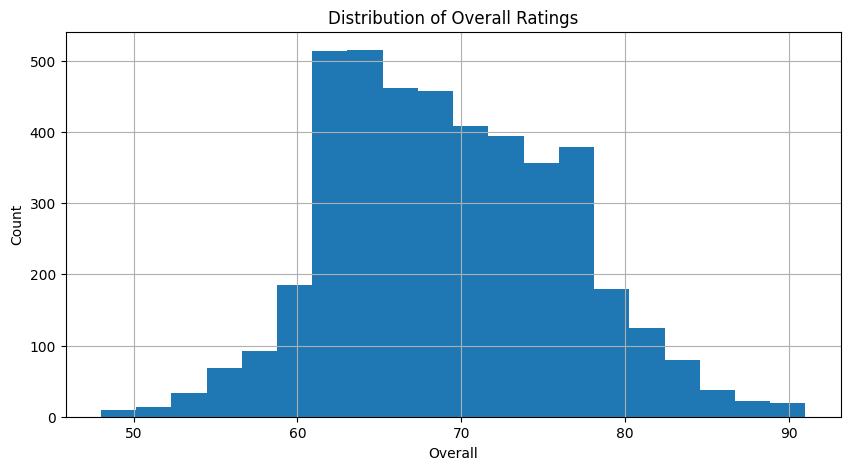

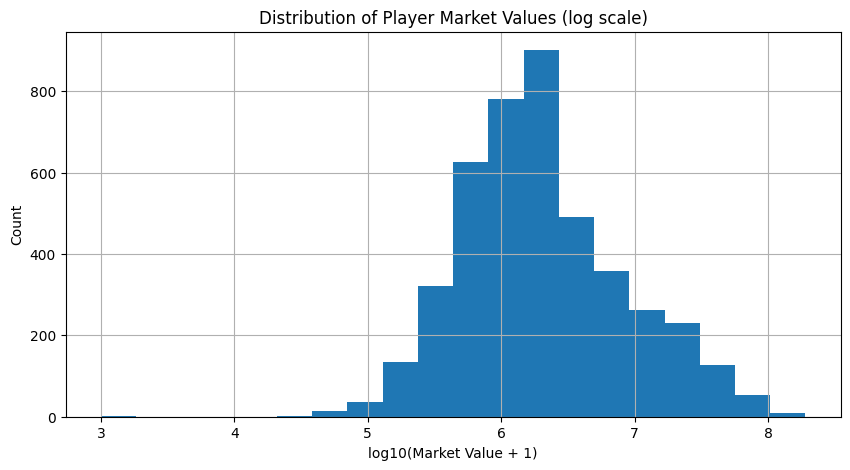

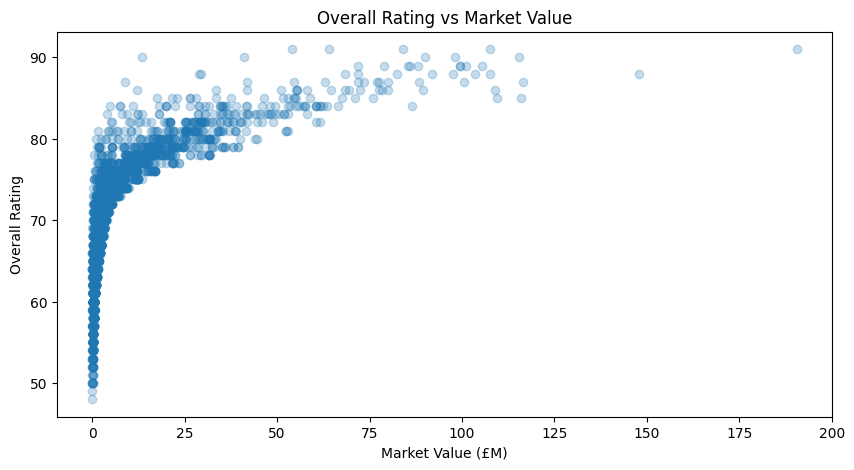

In [11]:
plt.figure()
player_data["Overall"].hist(bins=20)
plt.title("Distribution of Overall Ratings")
plt.xlabel("Overall")
plt.ylabel("Count")
plt.show()

plt.figure()
np.log10(player_data["value_gbp"] + 1).hist(bins=20)
plt.title("Distribution of Player Market Values (log scale)")
plt.xlabel("log10(Market Value + 1)")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.scatter(player_data["value_gbp"] / 1_000_000, player_data["Overall"], alpha=0.25)
plt.title("Overall Rating vs Market Value")
plt.xlabel("Market Value (£M)")
plt.ylabel("Overall Rating")
plt.show()

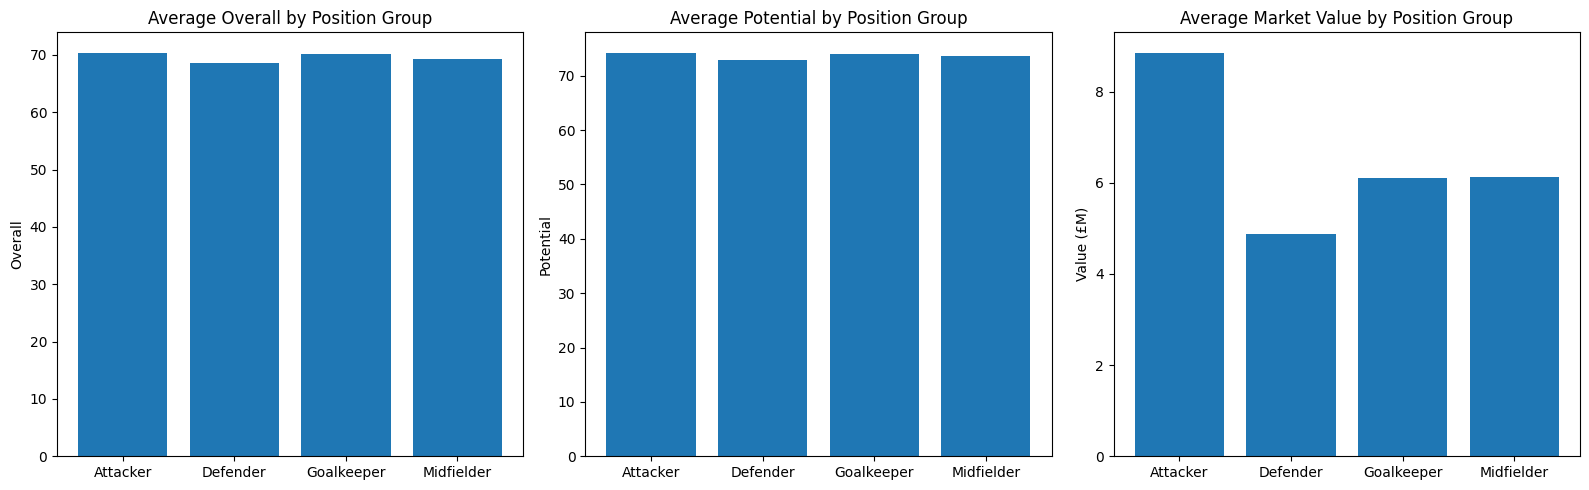

In [12]:
position_perf = player_data.groupby("position_group")[["Overall", "Potential", "value_gbp"]].mean()
position_perf["value_gbp"] = position_perf["value_gbp"] / 1_000_000

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(position_perf.index, position_perf["Overall"])
axes[0].set_title("Average Overall by Position Group")
axes[0].set_ylabel("Overall")

axes[1].bar(position_perf.index, position_perf["Potential"])
axes[1].set_title("Average Potential by Position Group")
axes[1].set_ylabel("Potential")

axes[2].bar(position_perf.index, position_perf["value_gbp"])
axes[2].set_title("Average Market Value by Position Group")
axes[2].set_ylabel("Value (£M)")

plt.tight_layout()
plt.show()

## 5. Weighted performance scoring

In [13]:
position_weights = {
    "Attacker": (0.60, 0.40),
    "Midfielder": (0.65, 0.35),
    "Defender": (0.70, 0.30),
    "Goalkeeper": (0.75, 0.25),
}

player_data["performance_score"] = player_data.apply(
    lambda row: position_weights[row["position_group"]][0] * row["Overall"] +
                position_weights[row["position_group"]][1] * row["Potential"],
    axis=1
)

player_data["value_score"] = (player_data["performance_score"] / player_data["value_gbp"]) * 1_000_000
player_data["wage_efficiency"] = (player_data["performance_score"] / player_data["wage_gbp"]) * 1_000

player_data[["Name", "position_group", "Overall", "Potential", "value_gbp", "performance_score", "value_score"]].head()

,Name,position_group,Overall,Potential,value_gbp,performance_score,value_score
1,Bruno Fernandes,Midfielder,86,87,"78,500,000.00",86.35,1.10
2,M. Acuña,Defender,85,85,"46,500,000.00",85.00,1.83
3,K. De Bruyne,Midfielder,91,91,"107,500,000.00",91.00,0.85
4,N. Barella,Midfielder,86,89,"89,500,000.00",87.05,0.97
6,D. Alaba,Defender,86,86,"55,500,000.00",86.00,1.55


In [14]:
top_value_players = (
    player_data.sort_values(["value_score", "performance_score"], ascending=False)
    [["Name", "Club", "position_group", "primary_position", "Age", "Overall", "Potential", "value_gbp", "wage_gbp", "performance_score", "value_score"]]
    .head(20)
)

top_value_players

,Name,Club,position_group,primary_position,Age,Overall,Potential,value_gbp,wage_gbp,performance_score,value_score
2524,13 E. Davids,Barnet,Midfielder,CM,39,64,64,"1,000.00",0.00,64.00,"64,000.00"
15795,14 D. Quigley,Bray Wanderers,Goalkeeper,GK,27,55,62,"30,000.00","1,000.00",56.75,"1,891.67"
10893,15 D. Doyle,Drogheda United,Defender,RB,33,53,53,"30,000.00","2,000.00",53.00,"1,766.67"
12417,Liu Tao,Chengdu Rongcheng F.C.,Defender,LCB,37,59,59,"40,000.00","1,000.00",59.00,"1,475.00"
14556,21 I. González,Zamora Fútbol Club,Defender,LCB,36,59,59,"40,000.00",500.00,59.00,"1,475.00"
8364,18 J. Bréchet,GFC Ajaccio,Defender,LCB,37,66,66,"45,000.00","2,000.00",66.00,"1,466.67"
16478,21 J. Pretel,Cusco Fútbol Club,Goalkeeper,GK,36,62,62,"45,000.00",500.00,62.00,"1,377.78"
15854,G. Morris,Gillingham,Goalkeeper,GK,38,63,63,"50,000.00","2,000.00",63.00,"1,260.00"
16116,21 Reguero,HJK Helsinki,Goalkeeper,GK,37,64,64,"60,000.00",500.00,64.00,"1,066.67"
16786,G. Arévalos,General Caballero (JLM),Goalkeeper,GK,37,64,64,"60,000.00",500.00,64.00,"1,066.67"


In [15]:
top_per_group = (
    player_data.sort_values(["position_group", "value_score", "performance_score"], ascending=[True, False, False])
    .groupby("position_group")
    .head(10)
    [["Name", "Club", "position_group", "primary_position", "Age", "Overall", "Potential", "value_gbp", "performance_score", "value_score"]]
)

top_per_group.head(20)

,Name,Club,position_group,primary_position,Age,Overall,Potential,value_gbp,performance_score,value_score
14599,Carlos Martínez,FC Andorra,Attacker,ST,36,57,57,"60,000.00",57.00,950.00
14256,20 M. Quinteros,CD Universidad de Concepción,Attacker,ST,30,57,57,"100,000.00",57.00,570.00
8964,R. Taylor,Grimsby Town,Attacker,ST,34,59,59,"110,000.00",59.00,536.36
14810,M. Singh,NorthEast United FC,Attacker,ST,21,51,61,"130,000.00",55.00,423.08
13676,F. Mihaljević,Finn Harps,Attacker,ST,30,56,56,"140,000.00",56.00,400.00
5378,14 A. Del Piero,Sydney FC,Attacker,ST,38,70,70,"190,000.00",70.00,368.42
9632,21 Jia Meilin,Jiangsu FC,Attacker,RW,30,57,57,"160,000.00",57.00,356.25
13448,20 R. Rojas,Atlético Bucaramanga,Attacker,ST,26,59,59,"170,000.00",59.00,347.06
14846,T. Al Mutairi,Al Batin,Attacker,ST,21,52,61,"180,000.00",55.60,308.89
15206,Y. Fawaz,Al Batin,Attacker,RW,19,52,65,"190,000.00",57.20,301.05


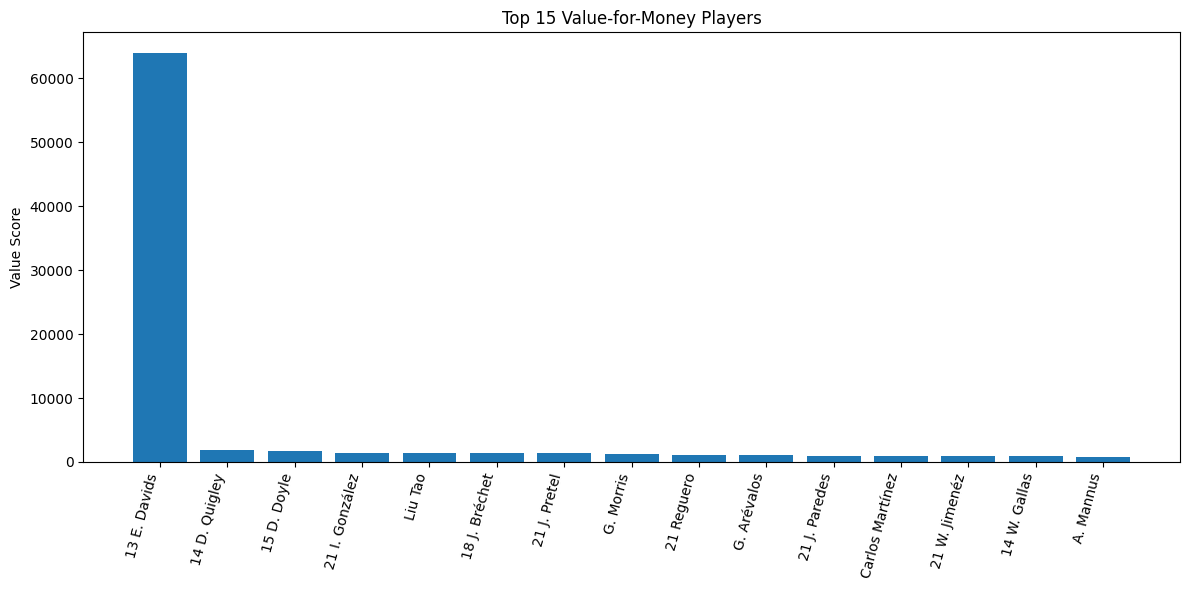

In [16]:
plt.figure(figsize=(12, 6))
plot_df = player_data.sort_values("value_score", ascending=False).head(15)
plt.bar(plot_df["Name"], plot_df["value_score"])
plt.xticks(rotation=75, ha="right")
plt.title("Top 15 Value-for-Money Players")
plt.ylabel("Value Score")
plt.tight_layout()
plt.show()

## 6. Budget-aware shortlist generation

In [17]:
group_medians = player_data.groupby("position_group").agg(
    median_perf=("performance_score", "median"),
    median_value=("value_gbp", "median")
).reset_index()

budget_candidates = player_data.merge(group_medians, on="position_group", how="left")
budget_candidates = budget_candidates[
    (budget_candidates["performance_score"] >= budget_candidates["median_perf"]) &
    (budget_candidates["value_gbp"] <= budget_candidates["median_value"])
].copy()

budget_shortlist = (
    budget_candidates.sort_values(["position_group", "value_score"], ascending=[True, False])
    .groupby("position_group")
    .head(8)
    [["Name", "Club", "position_group", "primary_position", "Age", "Overall", "Potential", "value_gbp", "performance_score", "value_score"]]
)

budget_shortlist

,Name,Club,position_group,primary_position,Age,Overall,Potential,value_gbp,performance_score,value_score
1089,L. Podolski,Górnik Zabrze,Attacker,RF,37,72,72,"800,000.00",72.00,90.00
1503,21 E. Paredes,Colo-Colo,Attacker,ST,39,73,73,"1,000,000.00",73.00,73.00
1723,J. Larrivey,Cosenza,Attacker,ST,37,73,73,"1,000,000.00",73.00,73.00
1774,D. Quintero,Houston Dynamo,Attacker,LW,34,72,72,"1,100,000.00",72.00,65.45
1760,16 M. Klose,Lazio,Attacker,ST,37,79,79,"1,300,000.00",79.00,60.77
1384,G. Burgstaller,SK Rapid Wien,Attacker,ST,33,72,72,"1,500,000.00",72.00,48.00
1577,S. Kagawa,Sint-Truidense VV,Attacker,LF,33,72,72,"1,500,000.00",72.00,48.00
2339,B. Cuesta,FBC Melgar,Attacker,ST,33,72,72,"1,500,000.00",72.00,48.00
1657,14 G. Heinze,Newell's Old Boys,Defender,LCB,35,74,74,"300,000.00",74.00,246.67
1152,Javi López,Adelaide United,Defender,RB,36,70,70,"350,000.00",70.00,200.00


## 7. Supervised machine learning for market value prediction

In [18]:
ml_df = player_data.copy()

feature_cols = [
    "Age", "Overall", "Potential", "wage_gbp", "Special",
    "international_reputation", "weak_foot", "skill_moves",
    "attacking_work_rate_num", "defensive_work_rate_num",
    "height_cm", "weight_lbs", "year_joined", "years_remaining",
    "Preferred Foot", "position_group", "primary_position"
]

target_col = "value_gbp"

X = ml_df[feature_cols]
y = np.log1p(ml_df[target_col])

numeric_features = [
    "Age", "Overall", "Potential", "wage_gbp", "Special",
    "international_reputation", "weak_foot", "skill_moves",
    "attacking_work_rate_num", "defensive_work_rate_num",
    "height_cm", "weight_lbs", "year_joined", "years_remaining",
]

categorical_features = ["Preferred Foot", "position_group", "primary_position"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    pred_log = pipeline.predict(X_test)

    y_test_actual = np.expm1(y_test)
    pred_actual = np.expm1(pred_log)

    mae = mean_absolute_error(y_test_actual, pred_actual)
    rmse = mean_squared_error(y_test_actual, pred_actual) ** 0.5
    r2 = r2_score(y_test_actual, pred_actual)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,Model,MAE,RMSE,R2
2,Gradient Boosting,"433,099.15","1,110,970.08",0.99
1,Random Forest,"541,410.01","2,160,236.94",0.97
0,Linear Regression,"1,490,087.09","6,357,872.68",0.76


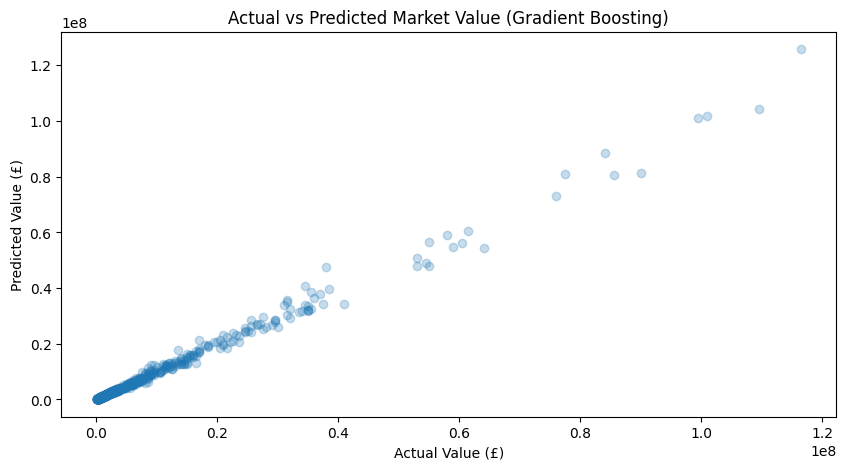

Best model: Gradient Boosting


In [20]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)
best_pred = np.expm1(best_pipeline.predict(X_test))
y_test_actual = np.expm1(y_test)

plt.figure()
plt.scatter(y_test_actual, best_pred, alpha=0.25)
plt.title(f"Actual vs Predicted Market Value ({best_model_name})")
plt.xlabel("Actual Value (£)")
plt.ylabel("Predicted Value (£)")
plt.show()

print("Best model:", best_model_name)

## 8. Unsupervised machine learning for player segmentation

In [21]:
cluster_features = player_data[
    ["Age", "Overall", "Potential", "wage_gbp", "value_gbp", "performance_score"]
].copy()

cluster_scaled = StandardScaler().fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_scaled)

player_data["cluster"] = clusters

cluster_profile = player_data.groupby("cluster").agg(
    players=("Name", "count"),
    avg_age=("Age", "mean"),
    avg_overall=("Overall", "mean"),
    avg_potential=("Potential", "mean"),
    avg_value_m=("value_gbp", lambda x: x.mean()/1_000_000),
    avg_wage=("wage_gbp", "mean"),
    avg_perf=("performance_score", "mean")
).round(2)

cluster_profile

,players,avg_age,avg_overall,avg_potential,avg_value_m,avg_wage,avg_perf
cluster,,,,,,,
0,1516,22.38,67.01,74.77,2.01,"4,708.21",69.58
1,1340,28.19,76.09,77.97,9.99,"27,115.30",76.71
2,156,26.84,84.75,87.12,58.32,"132,750.00",85.57
3,1334,26.89,63.15,65.87,0.61,"2,111.84",64.02


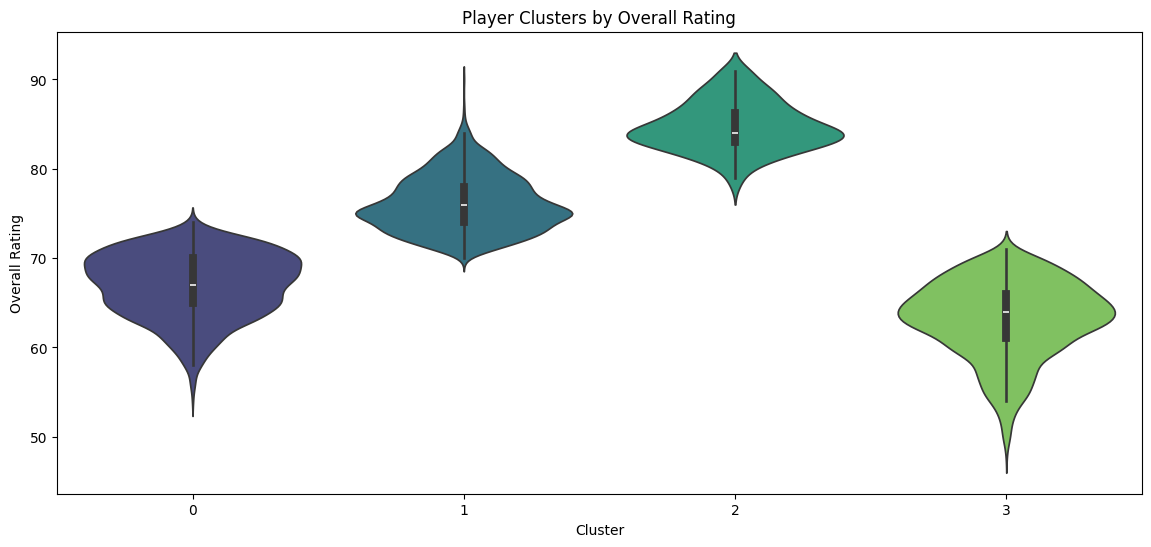

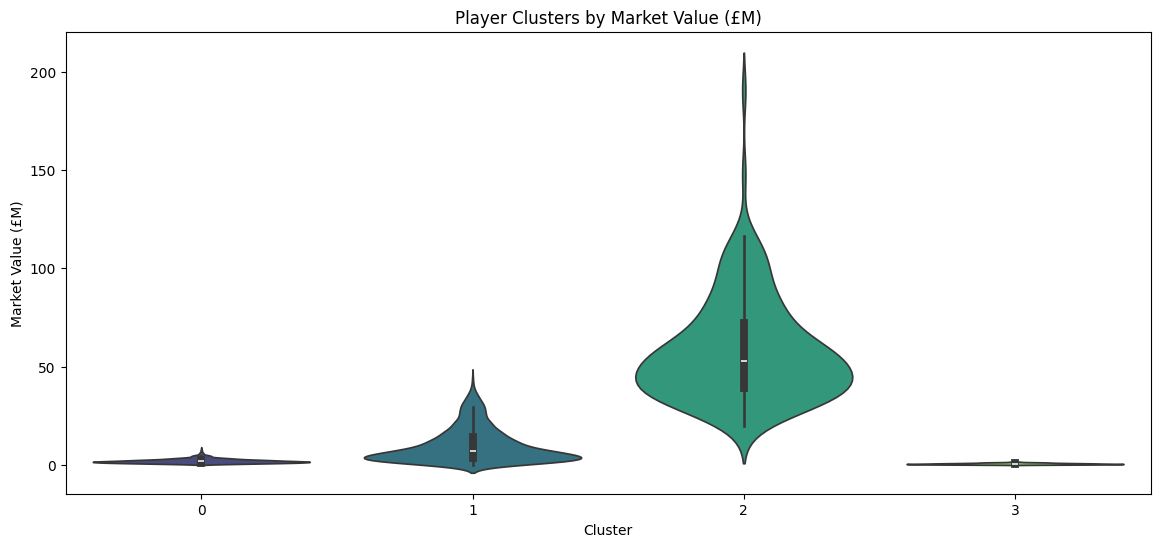

In [25]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.violinplot(x='cluster', y='Overall', data=player_data, palette='viridis')
plt.title('Player Clusters by Overall Rating')
plt.xlabel('Cluster')
plt.ylabel('Overall Rating')
plt.show()

plt.figure(figsize=(14, 6))
sns.violinplot(x='cluster', y=player_data['value_gbp']/1_000_000, data=player_data, palette='viridis')
plt.title('Player Clusters by Market Value (£M)')
plt.xlabel('Cluster')
plt.ylabel('Market Value (£M)')
plt.show()

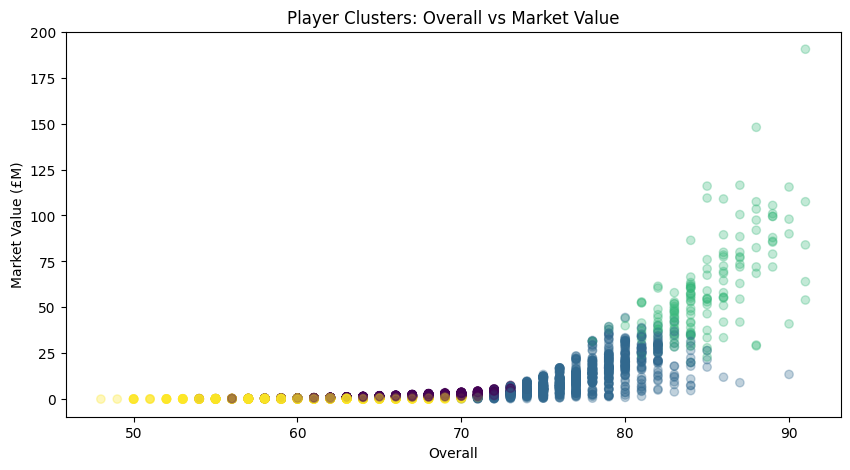

Silhouette Score: 0.307


In [22]:
plt.figure()
plt.scatter(
    player_data["Overall"],
    player_data["value_gbp"] / 1_000_000,
    c=player_data["cluster"],
    alpha=0.30
)
plt.title("Player Clusters: Overall vs Market Value")
plt.xlabel("Overall")
plt.ylabel("Market Value (£M)")
plt.show()

print("Silhouette Score:", round(silhouette_score(cluster_scaled, clusters), 3))

In [23]:
cluster_examples = (
    player_data.sort_values(["cluster", "value_score"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
    [["cluster", "Name", "Club", "position_group", "Age", "Overall", "Potential", "value_gbp", "performance_score", "value_score"]]
)

cluster_examples

,cluster,Name,Club,position_group,Age,Overall,Potential,value_gbp,performance_score,value_score
11907,0,M. Cudjoe,Dundee United,Attacker,18,55,71,"325,000.00",61.40,188.92
9180,0,21 C. Menacho,"Club Social, Cultural y Deportivo de Blooming",Midfielder,18,56,71,"325,000.00",61.25,188.46
15693,0,22 E. Morales,Atlanta United,Defender,17,54,77,"325,000.00",60.90,187.38
17096,0,L. Bergström,Peterborough United,Goalkeeper,19,56,75,"325,000.00",60.75,186.92
13844,0,E. Nuamah,FC Nordsjælland,Attacker,18,56,72,"350,000.00",62.40,178.29
2240,1,16 D. Duff,Shamrock Rovers,Midfielder,36,71,71,"130,000.00",71.00,546.15
5378,1,14 A. Del Piero,Sydney FC,Attacker,38,70,70,"190,000.00",70.00,368.42
15671,1,20 T. Howard,Colorado Rapids,Goalkeeper,40,71,71,"240,000.00",71.00,295.83
15887,1,E. Viviano,Fatih Karagümrük S.K.,Goalkeeper,36,72,72,"250,000.00",72.00,288.00
16036,1,S. Torrico,San Lorenzo de Almagro,Goalkeeper,42,72,72,"250,000.00",72.00,288.00


## 9. Export results

In [24]:
outputs = {
    "cleaned_player_data.csv": player_data,
    "top_value_players.csv": top_value_players,
    "top_players_per_group.csv": top_per_group,
    "budget_shortlist.csv": budget_shortlist,
    "model_results.csv": results_df,
    "cluster_profile.csv": cluster_profile.reset_index(),
    "cluster_examples.csv": cluster_examples
}

for filename, df_out in outputs.items():
    df_out.to_csv(filename, index=False)

print("Files exported:")
for filename in outputs:
    print("-", filename)

Files exported:
- cleaned_player_data.csv
- top_value_players.csv
- top_players_per_group.csv
- budget_shortlist.csv
- model_results.csv
- cluster_profile.csv
- cluster_examples.csv
